# DATASET: India Cost of Living 

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('data.csv')
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment
0,2018,Mumbai,100,80,12000,2000,2500,1500
1,2019,Mumbai,105,82,12500,2100,2600,1600
2,2020,Mumbai,110,78,13000,1900,2700,1700
3,2021,Mumbai,120,90,13500,2200,2800,1800
4,2022,Mumbai,135,100,14500,2400,3000,2000
5,2023,Mumbai,150,115,16500,2900,3400,2400
6,2024,Mumbai,165,120,18000,3200,3600,2600
7,2018,Pune,90,75,8000,1500,2000,1200
8,2019,Pune,95,78,8200,1550,2100,1300
9,2020,Pune,100,76,8500,1500,2200,1400


---
## PROJECT QUESTIONS

### 1) Convert Date into datetime
pd.to_datetime:
 This is a pandas function that converts data → datetime format text/number → actual date
%Y what this means:
4-digit year (2018) it converts 4 digit year to date


In [3]:
df["Year"] = pd.to_datetime(df["Year"], format="%Y")
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment
0,2018-01-01,Mumbai,100,80,12000,2000,2500,1500
1,2019-01-01,Mumbai,105,82,12500,2100,2600,1600
2,2020-01-01,Mumbai,110,78,13000,1900,2700,1700
3,2021-01-01,Mumbai,120,90,13500,2200,2800,1800
4,2022-01-01,Mumbai,135,100,14500,2400,3000,2000
5,2023-01-01,Mumbai,150,115,16500,2900,3400,2400
6,2024-01-01,Mumbai,165,120,18000,3200,3600,2600
7,2018-01-01,Pune,90,75,8000,1500,2000,1200
8,2019-01-01,Pune,95,78,8200,1550,2100,1300
9,2020-01-01,Pune,100,76,8500,1500,2200,1400


---
## Group data city-wise
so groupby is easy here but we have got multiple useage of groupby data as finding mean sum etc 
but if you see second one i am using .agg functoin also as to get and be more specific about data i am agreagating it to particular data

In [6]:
df.groupby("City").mean()


,Year,Food,Fuel,Rent,Transport,Utilities,Entertainment
City,,,,,,,
Delhi,2020-12-31 13:42:51.428571,119.285714,93.714286,12428.571429,2171.428571,2742.857143,1814.285714
Mumbai,2020-12-31 13:42:51.428571,126.428571,95.000000,14285.714286,2385.714286,2942.857143,1942.857143
Pune,2020-12-31 13:42:51.428571,112.857143,91.285714,9742.857143,1792.857143,2357.142857,1585.714286


In [7]:
df.groupby("City").agg({
    "Food": "mean",
    "Fuel": "mean",
    "Rent": "max"
})

,Food,Fuel,Rent
City,,,
Delhi,119.285714,93.714286,16000
Mumbai,126.428571,95.000000,18000
Pune,112.857143,91.285714,13000


---
## Calculate yearly % growth for each category per city
1} df.sort_values(by=['city','year'])=
First sort by City
Then inside each city, sort by Year


In [9]:
df = df.sort_values(by=["City", "Year"])
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment,Food_Growth_%,Fuel_Growth_%,Rent_Growth_%,Transport_Growth_%,Utilities_Growth_%,Entertainment_Growth_%
14,2018-01-01,Delhi,95,78,10000,1800,2300,1400,NaN,NaN,NaN,NaN,NaN,NaN
15,2019-01-01,Delhi,100,80,10500,1900,2400,1500,5.263158,2.564103,5.000000,5.555556,4.347826,7.142857
16,2020-01-01,Delhi,105,79,11000,1800,2500,1600,5.000000,-1.250000,4.761905,-5.263158,4.166667,6.666667
17,2021-01-01,Delhi,115,88,12000,2000,2600,1700,9.523810,11.392405,9.090909,11.111111,4.000000,6.250000
18,2022-01-01,Delhi,125,98,13000,2200,2800,1900,8.695652,11.363636,8.333333,10.000000,7.692308,11.764706
19,2023-01-01,Delhi,140,115,14500,2600,3200,2200,12.000000,17.346939,11.538462,18.181818,14.285714,15.789474
20,2024-01-01,Delhi,155,118,16000,2900,3400,2400,10.714286,2.608696,10.344828,11.538462,6.250000,9.090909
0,2018-01-01,Mumbai,100,80,12000,2000,2500,1500,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01,Mumbai,105,82,12500,2100,2600,1600,5.000000,2.500000,4.166667,5.000000,4.000000,6.666667
2,2020-01-01,Mumbai,110,78,13000,1900,2700,1700,4.761905,-4.878049,4.000000,-9.523810,3.846154,6.250000


step 2}= cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]
This creates a list of column names.
Because we want growth for all these categories, and instead of writing same code 6 times, we store their names in a list and use a loop.


step 3)= for col in cols:
df[col + "_Growth_%"] = df.groupby("City")[col].pct_change() * 100
df.groupby("City")=This groups data by city.
So pandas treats Mumbai, Pune, and Delhi separately.
That means growth is calculated inside each city only.
It will not compare Mumbai 2024 with Pune 2018 or anything wrong like that.
df.groupby("City")[col]==df.groupby("City")["Food"]
.pct_change()==This calculates percentage change from the previous row.
Formula is:
current
−
previous
previous
previous
current−previ
ous
​	df[col + "_Growth_%"]===This creates a new column name.
 


In [8]:
df = df.sort_values(by=["City", "Year"])

# list of categories
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# apply pct_change for each category per city
for col in cols:
    df[col + "_Growth_%"] = df.groupby("City")[col].pct_change() * 100

# result
print(df)


         Year    City  Food  Fuel   Rent  Transport  Utilities  Entertainment  \
14 2018-01-01   Delhi    95    78  10000       1800       2300           1400   
15 2019-01-01   Delhi   100    80  10500       1900       2400           1500   
16 2020-01-01   Delhi   105    79  11000       1800       2500           1600   
17 2021-01-01   Delhi   115    88  12000       2000       2600           1700   
18 2022-01-01   Delhi   125    98  13000       2200       2800           1900   
19 2023-01-01   Delhi   140   115  14500       2600       3200           2200   
20 2024-01-01   Delhi   155   118  16000       2900       3400           2400   
0  2018-01-01  Mumbai   100    80  12000       2000       2500           1500   
1  2019-01-01  Mumbai   105    82  12500       2100       2600           1600   
2  2020-01-01  Mumbai   110    78  13000       1900       2700           1700   
3  2021-01-01  Mumbai   120    90  13500       2200       2800           1800   
4  2022-01-01  Mumbai   135 

---
## Which city has highest inflation overall (2018–2024)?

step 1}==
total cost
df["Total"] = df[cols].sum(axis=1)
make a new column for total sum



In [13]:

df["Total"] = df[cols].sum(axis=1)
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment,Food_Growth_%,Fuel_Growth_%,Rent_Growth_%,Transport_Growth_%,Utilities_Growth_%,Entertainment_Growth_%,Total,Year_num
14,2018-01-01,Delhi,95,78,10000,1800,2300,1400,NaN,NaN,NaN,NaN,NaN,NaN,15673,2018
15,2019-01-01,Delhi,100,80,10500,1900,2400,1500,5.263158,2.564103,5.000000,5.555556,4.347826,7.142857,16480,2019
16,2020-01-01,Delhi,105,79,11000,1800,2500,1600,5.000000,-1.250000,4.761905,-5.263158,4.166667,6.666667,17084,2020
17,2021-01-01,Delhi,115,88,12000,2000,2600,1700,9.523810,11.392405,9.090909,11.111111,4.000000,6.250000,18503,2021
18,2022-01-01,Delhi,125,98,13000,2200,2800,1900,8.695652,11.363636,8.333333,10.000000,7.692308,11.764706,20123,2022
19,2023-01-01,Delhi,140,115,14500,2600,3200,2200,12.000000,17.346939,11.538462,18.181818,14.285714,15.789474,22755,2023
20,2024-01-01,Delhi,155,118,16000,2900,3400,2400,10.714286,2.608696,10.344828,11.538462,6.250000,9.090909,24973,2024
0,2018-01-01,Mumbai,100,80,12000,2000,2500,1500,NaN,NaN,NaN,NaN,NaN,NaN,18180,2018
1,2019-01-01,Mumbai,105,82,12500,2100,2600,1600,5.000000,2.500000,4.166667,5.000000,4.000000,6.666667,18987,2019
2,2020-01-01,Mumbai,110,78,13000,1900,2700,1700,4.761905,-4.878049,4.000000,-9.523810,3.846154,6.250000,19488,2020


step 2)== create year number column
df["Year_num"] = df["Year"].dt.year

In [14]:

df["Year_num"] = df["Year"].dt.year
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment,Food_Growth_%,Fuel_Growth_%,Rent_Growth_%,Transport_Growth_%,Utilities_Growth_%,Entertainment_Growth_%,Total,Year_num
14,2018-01-01,Delhi,95,78,10000,1800,2300,1400,NaN,NaN,NaN,NaN,NaN,NaN,15673,2018
15,2019-01-01,Delhi,100,80,10500,1900,2400,1500,5.263158,2.564103,5.000000,5.555556,4.347826,7.142857,16480,2019
16,2020-01-01,Delhi,105,79,11000,1800,2500,1600,5.000000,-1.250000,4.761905,-5.263158,4.166667,6.666667,17084,2020
17,2021-01-01,Delhi,115,88,12000,2000,2600,1700,9.523810,11.392405,9.090909,11.111111,4.000000,6.250000,18503,2021
18,2022-01-01,Delhi,125,98,13000,2200,2800,1900,8.695652,11.363636,8.333333,10.000000,7.692308,11.764706,20123,2022
19,2023-01-01,Delhi,140,115,14500,2600,3200,2200,12.000000,17.346939,11.538462,18.181818,14.285714,15.789474,22755,2023
20,2024-01-01,Delhi,155,118,16000,2900,3400,2400,10.714286,2.608696,10.344828,11.538462,6.250000,9.090909,24973,2024
0,2018-01-01,Mumbai,100,80,12000,2000,2500,1500,NaN,NaN,NaN,NaN,NaN,NaN,18180,2018
1,2019-01-01,Mumbai,105,82,12500,2100,2600,1600,5.000000,2.500000,4.166667,5.000000,4.000000,6.666667,18987,2019
2,2020-01-01,Mumbai,110,78,13000,1900,2700,1700,4.761905,-4.878049,4.000000,-9.523810,3.846154,6.250000,19488,2020


step 3)==inflation = df[df["Year_num"].isin([2018, 2024])]
To calculate inflation from starting year to ending year.
df["Year_num"].isin([2018, 2024])
Checks each row:
is year 2018?
or is year 2024?
It returns True/False like:


step 4)== pivot = inflation.pivot(index="City", columns="Year_num", values="Total")
This is the most important step.
What pivot does
It rearranges data.

In [16]:
pivot = inflation.pivot(index="City", columns="Year_num", values="Total")
pivot

Year_num,2018,2024
City,,
Delhi,15673,24973
Mumbai,18180,27685
Pune,12865,20463


step 5) == pivot["Inflation_%"] = ((pivot[2024] - pivot[2018]) / pivot[2018]) * 100


In [ ]:
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# total cost
df["Total"] = df[cols].sum(axis=1)

# create year number column
df["Year_num"] = df["Year"].dt.year

# keep only 2018 and 2024
inflation = df[df["Year_num"].isin([2018, 2024])]

# pivot correctly
pivot = inflation.pivot(index="City", columns="Year_num", values="Total")

# calculate inflation %
pivot["Inflation_%"] = ((pivot[2024] - pivot[2018]) / pivot[2018]) * 100

print(pivot)
print()
print("Highest inflation city:", pivot["Inflation_%"].idxmax())

Year_num   2018   2024  Inflation_%
City                               
Delhi     15673  24973    59.337715
Mumbai    18180  27685    52.282728
Pune      12865  20463    59.059464

Highest inflation city: Delhi


---
## Which category grew the fastest across all cities?

step 1)== # Step 3: filter only 2018 & 2024
data = df[df["Year_num"].isin([2018, 2024])]
Checks each row:
is year 2018?
or is year 2024?
It returns True/False like:
 Step 4: combine all cities
grouped = data.groupby("Year_num")[cols].sum()
growth = ((grouped.loc[2024] - grouped.loc[2018]) / grouped.loc[2018]) * 100
calculating growth percent here
sorting the column # Step 6: sort
growth_sorted = growth.sort_values(ascending=False)
print(growth_sorted)
print(" Highest Growth Category:", growth_sorted.idxmax())
it will find max elem from sorting 


In [ ]:
# Step 1: columns
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

# Step 2: extract year
df["Year_num"] = df["Year"].dt.year

# Step 3: filter only 2018 & 2024
data = df[df["Year_num"].isin([2018, 2024])]

# Step 4: combine all cities
grouped = data.groupby("Year_num")[cols].sum()

# Step 5: calculate growth %
growth = ((grouped.loc[2024] - grouped.loc[2018]) / grouped.loc[2018]) * 100

# Step 6: sort
growth_sorted = growth.sort_values(ascending=False)

print(growth_sorted)
print(" Highest Growth Category:", growth_sorted.idxmax())

Entertainment    73.170732
Food             63.157895
Transport        58.490566
Rent             56.666667
Fuel             52.789700
Utilities        44.117647
dtype: float64
 Highest Growth Category: Entertainment


---
## Find year with highest inflation spike

step 1) == df["Total"] = df[cols].sum(axis=1)
df["Year_num"] = df["Year"].dt.year 
HERE making new two columns total year num 
yearly = df.groupby("Year_num")["Total"].sum()
here they are grouping on seperate year and total

inflation = yearly.pct_change() * 100 here calculating infaltin year by 
sorting the inflation 
then printing maximum

In [21]:
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

df["Total"] = df[cols].sum(axis=1)
df["Year_num"] = df["Year"].dt.year
yearly = df.groupby("Year_num")["Total"].sum()
inflation = yearly.pct_change() * 100
print(inflation.sort_values(ascending=False))
print(" Highest Inflation Spike Year:", inflation.idxmax())

Year_num
2023    13.639390
2024     9.853971
2022     9.058241
2021     6.673552
2019     4.435121
2020     3.193277
2018          NaN
Name: Total, dtype: float64
 Highest Inflation Spike Year: 2023


---
## Calculate CAGR (Compound Annual Growth Rate) for Rent

If something grew at a steady rate every year, what would that rate be? it is called cagr
Formula==>
CAGR=( 
Initial
Final
​	
 ) 
n
1
​	
 
 −1
 average yearly growth over period

as step 1 and step 2 we already know as the real one start from step 3
step 3) ==>
rent_grouped = rent_data.groupby("Year_num")["Rent"].sum()
It groups the data by year and adds rent values of all cities together.
the end out of this line loook like this 
2018    30000
2024    46000
Because question is asking overall Rent CAGR across all cities.


initial = rent_grouped.loc[2018]
Takes the 2018 rent total and stores it in initial.
final = rent_grouped.loc[2024]
takes the 2024 rent total and stores in final 

Step 5: CAGR formula
n = 6  # years
cagr = ((final / initial) ** (1/n) - 1) * 100
applying formula of cagr which is already known 

In [ ]:
# Step 1: extract year
df["Year_num"] = df["Year"].dt.year

# Step 2: get only Rent data for 2018 & 2024
rent_data = df[df["Year_num"].isin([2018, 2024])]

# Step 3: combine all cities
rent_grouped = rent_data.groupby("Year_num")["Rent"].sum()

# Step 4: get values
initial = rent_grouped.loc[2018]
final = rent_grouped.loc[2024]

# Step 5: CAGR formula
n = 6  # years
cagr = ((final / initial) ** (1/n) - 1) * 100

print("Rent CAGR:", cagr)

Rent CAGR: 7.769557718647291


---
## Compare Fuel vs Food growth trend


In [6]:
# Step 1: extract year
df["Year_num"] = df["Year"].dt.year

# Step 2: combine all cities
yearly = df.groupby("Year_num")[["Food", "Fuel"]].sum()

# Step 3: calculate growth %
growth = yearly.pct_change() * 100

print(growth)

               Food       Fuel
Year_num                      
2018            NaN        NaN
2019       5.263158   3.004292
2020       5.000000  -2.916667
2021       9.523810  12.875536
2022      10.144928  11.406844
2023      10.526316  16.723549
2024      10.714286   4.093567


---
## Compute moving average (window = 3 years) for each category

In [8]:
df = df.sort_values(["City", "Year"])
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

for col in cols:
    df[col + "_MA3"] = df.groupby("City")[col].rolling(window=3).mean().reset_index(level=0, drop=True)

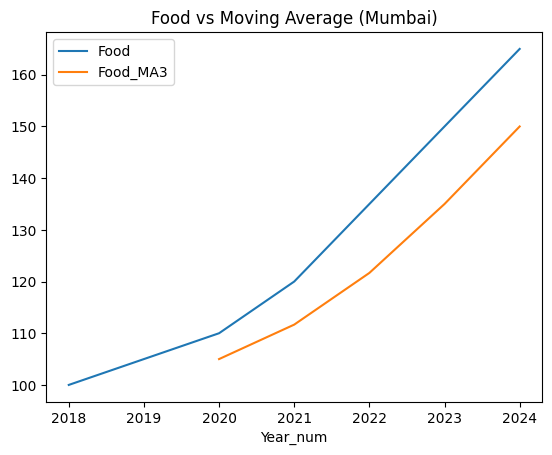

In [9]:
import matplotlib.pyplot as plt

city = "Mumbai"

df[df["City"] == city].plot(x="Year_num", y=["Food", "Food_MA3"])
plt.title("Food vs Moving Average (Mumbai)")
plt.show()

In [10]:
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment,Year_num,Food_MA3,Fuel_MA3,Rent_MA3,Transport_MA3,Utilities_MA3,Entertainment_MA3
14,2018-01-01,Delhi,95,78,10000,1800,2300,1400,2018,NaN,NaN,NaN,NaN,NaN,NaN
15,2019-01-01,Delhi,100,80,10500,1900,2400,1500,2019,NaN,NaN,NaN,NaN,NaN,NaN
16,2020-01-01,Delhi,105,79,11000,1800,2500,1600,2020,100.000000,79.000000,10500.000000,1833.333333,2400.000000,1500.000000
17,2021-01-01,Delhi,115,88,12000,2000,2600,1700,2021,106.666667,82.333333,11166.666667,1900.000000,2500.000000,1600.000000
18,2022-01-01,Delhi,125,98,13000,2200,2800,1900,2022,115.000000,88.333333,12000.000000,2000.000000,2633.333333,1733.333333
19,2023-01-01,Delhi,140,115,14500,2600,3200,2200,2023,126.666667,100.333333,13166.666667,2266.666667,2866.666667,1933.333333
20,2024-01-01,Delhi,155,118,16000,2900,3400,2400,2024,140.000000,110.333333,14500.000000,2566.666667,3133.333333,2166.666667
0,2018-01-01,Mumbai,100,80,12000,2000,2500,1500,2018,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01,Mumbai,105,82,12500,2100,2600,1600,2019,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,Mumbai,110,78,13000,1900,2700,1700,2020,105.000000,80.000000,12500.000000,2000.000000,2600.000000,1600.000000


---
## Plot year-wise total cost trend for each city

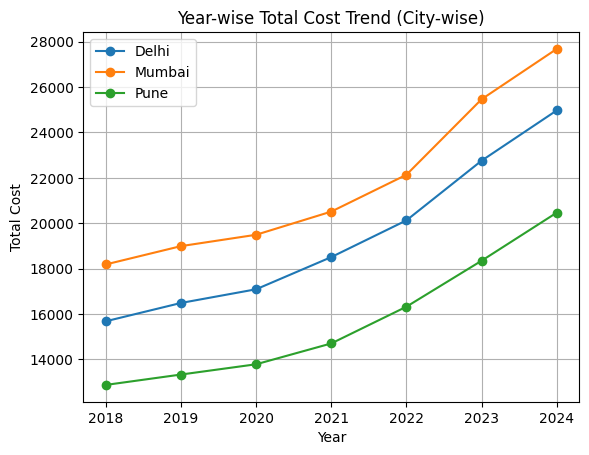

In [11]:
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]
df["Total"] = df[cols].sum(axis=1)
df["Year_num"] = df["Year"].dt.year
import matplotlib.pyplot as plt

cities = df["City"].unique()

for city in cities:
    city_data = df[df["City"] == city]
    plt.plot(city_data["Year_num"], city_data["Total"], marker='o', label=city)

plt.title("Year-wise Total Cost Trend (City-wise)")
plt.xlabel("Year")
plt.ylabel("Total Cost")
plt.legend()
plt.grid()

plt.show()

---
## Bar chart: Category comparison (latest year)

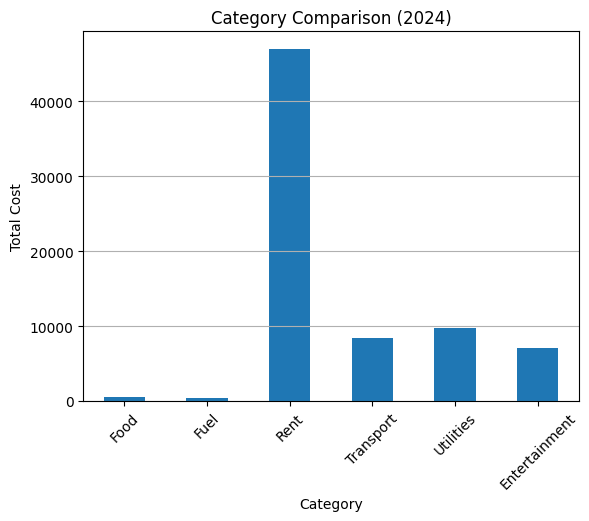

In [13]:
latest = df[df["Year"].dt.year == 2024]
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

category_totals = latest[cols].sum()
import matplotlib.pyplot as plt

category_totals.plot(kind="bar")

plt.title("Category Comparison (2024)")
plt.xlabel("Category")
plt.ylabel("Total Cost")
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

---
## Pie chart: Expense distribution per city

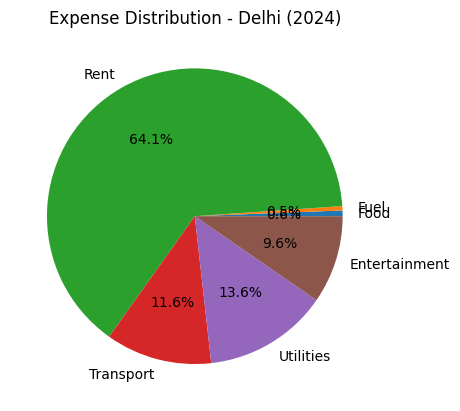

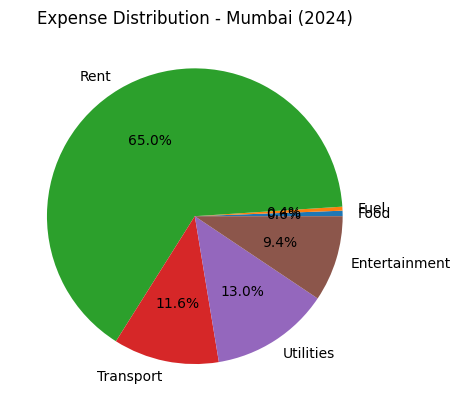

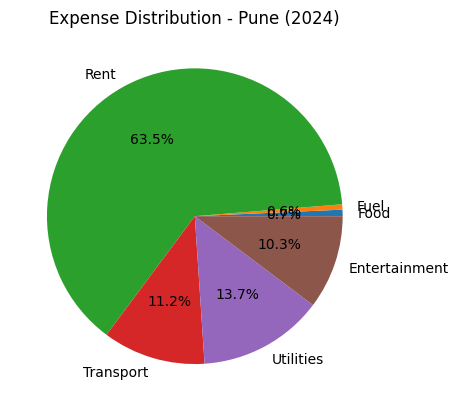

In [14]:
latest = df[df["Year"].dt.year == 2024]
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]
import matplotlib.pyplot as plt

cities = latest["City"].unique()

for city in cities:
    city_data = latest[latest["City"] == city]
    
    values = city_data[cols].iloc[0]

    plt.figure()
    plt.pie(values, labels=cols, autopct='%1.1f%%')
    plt.title(f"Expense Distribution - {city} (2024)")
    
    plt.show()

---
## Predict 2025 cost using average growth rate

Core Idea
2025 Value=2024 Value×(1+Average Growth)

In [15]:
df = df.sort_values(["City", "Year"])

In [16]:
df

,Year,City,Food,Fuel,Rent,Transport,Utilities,Entertainment,Year_num,Food_MA3,Fuel_MA3,Rent_MA3,Transport_MA3,Utilities_MA3,Entertainment_MA3,Total
14,2018-01-01,Delhi,95,78,10000,1800,2300,1400,2018,NaN,NaN,NaN,NaN,NaN,NaN,15673
15,2019-01-01,Delhi,100,80,10500,1900,2400,1500,2019,NaN,NaN,NaN,NaN,NaN,NaN,16480
16,2020-01-01,Delhi,105,79,11000,1800,2500,1600,2020,100.000000,79.000000,10500.000000,1833.333333,2400.000000,1500.000000,17084
17,2021-01-01,Delhi,115,88,12000,2000,2600,1700,2021,106.666667,82.333333,11166.666667,1900.000000,2500.000000,1600.000000,18503
18,2022-01-01,Delhi,125,98,13000,2200,2800,1900,2022,115.000000,88.333333,12000.000000,2000.000000,2633.333333,1733.333333,20123
19,2023-01-01,Delhi,140,115,14500,2600,3200,2200,2023,126.666667,100.333333,13166.666667,2266.666667,2866.666667,1933.333333,22755
20,2024-01-01,Delhi,155,118,16000,2900,3400,2400,2024,140.000000,110.333333,14500.000000,2566.666667,3133.333333,2166.666667,24973
0,2018-01-01,Mumbai,100,80,12000,2000,2500,1500,2018,NaN,NaN,NaN,NaN,NaN,NaN,18180
1,2019-01-01,Mumbai,105,82,12500,2100,2600,1600,2019,NaN,NaN,NaN,NaN,NaN,NaN,18987
2,2020-01-01,Mumbai,110,78,13000,1900,2700,1700,2020,105.000000,80.000000,12500.000000,2000.000000,2600.000000,1600.000000,19488


In [17]:
df["Year_num"] = df["Year"].dt.year
cols = ["Food", "Fuel", "Rent", "Transport", "Utilities", "Entertainment"]

for col in cols:
    df[col + "_growth"] = df.groupby("City")[col].pct_change()
avg_growth = df.groupby("City")[[col + "_growth" for col in cols]].mean()
latest = df[df["Year_num"] == 2024].set_index("City")
predictions = pd.DataFrame(index=latest.index)

for col in cols:
    predictions[col + "_2025"] = latest[col] * (1 + avg_growth[col + "_growth"])
print(predictions)

         Food_2025   Fuel_2025     Rent_2025  Transport_2025  Utilities_2025  \
City                                                                           
Delhi   168.225867  126.658403  17308.518302     3147.098311     3630.874250   
Mumbai  179.427579  128.693101  19269.127214     3474.851916     3827.450406   
Pune    157.030509  127.497936  14109.235376     2473.480150     2961.911489   

        Entertainment_2025  
City                        
Delhi          2626.818450  
Mumbai         2852.388344  
Pune           2305.774986  
